# Scenario 3: Vehicle removal and stop reallocation
This notebook tests what happens when some vehicles become unavailable for a selected day. Stops from the removed vehicles must then be reassigned to the remaining fleet. The scenario combines predicted service time, delivery volume, capacity limits, and delivery windows in one optimisation model. As in the earlier scenarios, the purpose is to demonstrate short-term planning support in a simplified proof-of-concept setting.

## Import libraries

The same main libraries are used again. Pandas and NumPy are used for data preparation, Matplotlib for visualisation, and OR-Tools for optimisation. In this scenario, OR-Tools is used to reassign stops after part of the fleet has been removed.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\computation\expressions.py:22: UserWarning: Pandas requires version '2.10.2' or newer of 'numexpr' (version '2.8.7' currently installed).
  from pandas.core.computation.check import NUMEXPR_INSTALLED
C:\Users\tuvap\anaconda3\Lib\site-packages\pandas\core\arrays\masked.py:56: UserWarning: Pandas requires version '1.4.2' or newer of 'bottleneck' (version '1.3.7' currently installed).
  from pandas.core import (


## Set scenario parameters and column names

As in the previous scenario, key settings are defined at the start of the notebook. The selected date determines which delivery day is analysed, while the number of vehicles included and removed controls the size of the disruption. Capacity and time-window limits are also set here. Column names are again stored as variables to make the later steps cleaner and easier to adjust.

In [ ]:
chosenDate = "2025-04-22"
topVehicleCount = 10
vehiclesToRemove = 2

fromHour = 8
toHour = 15
capacity = 42
endOfDay = 24 * 60
solveTime = 10

customerColumn = "Kundenr"
dateColumn = "Dato"
shiftColumn = "Kjøreskift ID"
startWindow = "Leveringsvindu fra"
endWindow = "Leveringsvindu til"
predColumn = "predikert_leveringstid"
volumeColumn = "Levert volum (m3)"

## Define helper functions

The same helper functions are reused here. Clock times are converted to minutes because OR-Tools requires numerical values. A second helper function adds labels to the charts so vehicle loads can be read directly from the figures.

In [ ]:
def toMinutes(timeValue):
    return timeValue.hour * 60 + timeValue.minute

def addLabels(axis, bars, values, bottom=None):
    for number, bar in enumerate(bars):
        value = values[number]

        if value <= 0:
            continue

        if bottom is None:
            height = value
        else:
            height = bottom[number] + value

        axis.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.3,
            f"{height:.1f}",
            ha="center",
            va="bottom",
            fontsize=9
        )

## Load prediction and historical data

As in the previous scenarios, the prepared prediction file and historical dataset are loaded and aligned so they can be used together. Predicted service times provide model input, while the historical data provides route structure, vehicle assignments, volumes, and delivery windows. Date and time fields are cleaned so filtering, merging, and optimisation can be performed consistently.

In [ ]:
predData = pd.read_csv("predictions.csv", low_memory=False)
historyData = pd.read_csv("merged_clean_7years.csv", low_memory=False)

predData.columns = predData.columns.str.strip()
historyData.columns = historyData.columns.str.strip()

predData[dateColumn] = pd.to_datetime(predData[dateColumn], errors="coerce")
historyData[dateColumn] = pd.to_datetime(historyData[dateColumn], errors="coerce")
historyData[startWindow] = pd.to_datetime(historyData[startWindow], errors="coerce")
historyData[endWindow] = pd.to_datetime(historyData[endWindow], errors="coerce")

predData["mergeDate"] = predData[dateColumn].dt.date
historyData["mergeDate"] = historyData[dateColumn].dt.date

## Merge predictions with operational delivery data

As in the earlier scenarios, prediction data is merged with operational data so each delivery contains both forecasted service time and the planning information needed for optimisation. The selected date and time period are then filtered to create one scenario dataset. Rows with missing key values are removed, since customer, vehicle, time-window, and service-time information are required in the next steps.

In [ ]:
historySmall = historyData[[
    customerColumn,
    "mergeDate",
    shiftColumn,
    volumeColumn,
    startWindow,
    endWindow]].copy()

data = predData.merge(historySmall, on=[customerColumn, "mergeDate"], how="left")
data = data.rename(columns={volumeColumn: "volume"})
chosenDate = pd.to_datetime(chosenDate).date()

scenarioData = data[(data["mergeDate"] == chosenDate) & (data[startWindow].dt.hour.between(fromHour, toHour))].copy()
scenarioData["volume"] = pd.to_numeric(scenarioData["volume"], errors="coerce").fillna(0)
scenarioData["serviceTime"] = pd.to_numeric(scenarioData[predColumn], errors="coerce")
scenarioData = scenarioData.dropna(subset=[customerColumn, shiftColumn, startWindow, endWindow, "serviceTime"])

print("Rows:", len(scenarioData))

Rows: 117


## Select vehicles and create stop-level data

With the scenario dataset prepared, the vehicles with the highest total volume are selected for analysis. This focuses the test on the most relevant part of the fleet, where removing vehicles is likely to create the largest disruption. The data is then grouped to stop level so each delivery appears once with assigned vehicle, volume, service time, and time windows. As in previous scenarios, the time windows are also converted to minutes before optimisation.

In [ ]:
topVehicles = (
    scenarioData.groupby(shiftColumn)["volume"]
    .sum()
    .sort_values(ascending=False)
    .head(topVehicleCount)
    .index
    .tolist())

scenarioData = scenarioData[scenarioData[shiftColumn].isin(topVehicles)].copy()

stops = (
    scenarioData
    .groupby([customerColumn, startWindow, endWindow, shiftColumn], as_index=False)
    .agg( stopVolume=("volume", "sum"), serviceTime=("serviceTime", "mean")))

stops["startMin"] = stops[startWindow].apply(toMinutes)
stops["endMin"] = stops[endWindow].apply(toMinutes)

## Choose vehicles to remove

A vehicle summary table is created by aggregating total assigned volume per vehicle. From the selected fleet, the vehicles with the lowest workload are removed from the scenario. This creates a clear disruption case where their stops must be reassigned to the remaining fleet. Using the lowest-volume vehicles is a simplification, but it gives a consistent and reproducible way to test fleet unavailability.

In [ ]:
vehicleTable = (
    stops.groupby(shiftColumn, as_index=False)
    .agg(totalVolume=("stopVolume", "sum"))
    .sort_values("totalVolume", ascending=False))

removedVehicles = (
    vehicleTable.sort_values("totalVolume")
    .head(vehiclesToRemove)[shiftColumn]
    .astype(int)
    .tolist())

remainingVehicles = [
    int(vehicle)
    for vehicle in topVehicles
    if int(vehicle) not in removedVehicles]

print("Removed vehicles:", removedVehicles)
print("Remaining vehicles:", remainingVehicles)

Removed vehicles: [5555057, 5555121]
Remaining vehicles: [5555035, 5555135, 5555119, 5555075, 5555033, 5555099, 5555071, 5555115]


## Prepare lists for OR-Tools

The remaining vehicles are mapped to internal solver IDs used by OR-Tools. As in the previous scenarios, stop volume, service time, and delivery windows are converted into lists, with the depot added as the first node. A simplified travel time matrix is also created. This prepares the final inputs for the optimisation model.

In [ ]:
vehicleToNumber = { vehicle: number for number, vehicle in enumerate(remainingVehicles)}
numberToVehicle = { number: vehicle for vehicle, number in vehicleToNumber.items()}

stopCount = len(stops)
vehicleCount = len(remainingVehicles)

volumeList = [0] + stops["stopVolume"].tolist()
serviceList = [0] + stops["serviceTime"].fillna(0).round().astype(int).tolist()
startList = [0] + stops["startMin"].tolist()
endList = [endOfDay] + stops["endMin"].tolist()

travelTime = [
    [0 if startStop == endStop else 1 for endStop in range(stopCount + 1)]
    for startStop in range(stopCount + 1)]

## Build the OR-Tools routing model

The routing model is now built for the remaining vehicles after the removals. Much of the same OR-Tools setup from the earlier scenarios is reused, but here it is used for a vehicle removal case. Callbacks are again used to read travel time, stop volume, and service time during the search. Capacity limits are added so the remaining vehicles do not get too much load, while a time dimension makes sure reassigned stops still follow their delivery windows. Using the same model structure gives consistency across scenarios, while the changed inputs test how the system handles fewer vehicles.

In [ ]:
manager = pywrapcp.RoutingIndexManager(stopCount + 1, vehicleCount, 0)
routing = pywrapcp.RoutingModel(manager)

def travelCallback(startIndex, endIndex):
    startStop = manager.IndexToNode(startIndex)
    endStop = manager.IndexToNode(endIndex)

    return travelTime[startStop][endStop]

def volumeCallback(startIndex):
    stopNumber = manager.IndexToNode(startIndex)

    return int(volumeList[stopNumber] * 1000)

def timeCallback(startIndex, endIndex):
    startStop = manager.IndexToNode(startIndex)
    endStop = manager.IndexToNode(endIndex)

    return travelTime[startStop][endStop] + serviceList[startStop]

travelIndex = routing.RegisterTransitCallback(travelCallback)
routing.SetArcCostEvaluatorOfAllVehicles(travelIndex)

volumeIndex = routing.RegisterUnaryTransitCallback(volumeCallback)
routing.AddDimensionWithVehicleCapacity( volumeIndex, 0, [int(capacity * 1000)] * vehicleCount, True, "Capacity")
timeIndex = routing.RegisterTransitCallback(timeCallback)
routing.AddDimension( timeIndex, 600, endOfDay, False, "Time")

timeDim = routing.GetDimensionOrDie("Time")

## Add time windows and keep existing vehicle assignments

Part of this step reuses the same time-window logic from the earlier scenarios, where each stop must be served within its allowed delivery period. The new element here is that stops already assigned to vehicles that still remain are locked to those vehicles. This means the model mainly reallocates stops from removed vehicles instead of rebuilding the whole plan. Keeping as much of the original schedule as possible makes the scenario more realistic, since planners often prefer smaller changes when disruptions happen.

In [ ]:
for stopNumber in range(1, stopCount + 1):
    stopIndex = manager.NodeToIndex(stopNumber)

    timeDim.CumulVar(stopIndex).SetRange( int(startList[stopNumber]), int(endList[stopNumber]))

for stopNumber in range(1, stopCount + 1):
    oldVehicle = int(stops.loc[stopNumber - 1, shiftColumn])

    if oldVehicle in vehicleToNumber:
        routing.VehicleVar(manager.NodeToIndex(stopNumber)).SetValue( vehicleToNumber[oldVehicle])

## Solve the reallocation problem

The same OR-Tools search structure from the earlier scenarios is reused here, but now it is solving a vehicle removal case. The solver first finds a feasible reallocation plan and then tries to improve it within the time limit. If no solution is found, it means the remaining fleet cannot cover all stops while respecting the given capacity and time constraints.

In [ ]:
params = pywrapcp.DefaultRoutingSearchParameters()

params.first_solution_strategy = routing_enums_pb2.FirstSolutionStrategy.PARALLEL_CHEAPEST_INSERTION
params.local_search_metaheuristic = routing_enums_pb2.LocalSearchMetaheuristic.GUIDED_LOCAL_SEARCH
params.time_limit.FromSeconds(solveTime)

solution = routing.SolveWithParameters(params)

if solution is None:
    raise RuntimeError("No feasible solution found")

print("Solution found")

Solution found


## Extract new vehicle assignments

After the solver finds a solution, the new vehicle assignment for each stop is extracted from the model output. As in earlier scenarios, internal OR-Tools numbers are converted back to the original vehicle IDs so the results are easier to interpret. The original vehicle is then compared with the new assigned vehicle for each stop. Focus is placed on stops from removed vehicles, since these are the deliveries that needed reallocation. This step shows clearly how the remaining fleet absorbed the disruption and which stops had to be moved.

In [ ]:
stopToVehicle = {}

for vehicleNumber in range(vehicleCount):
    routeIndex = routing.Start(vehicleNumber)

    while not routing.IsEnd(routeIndex):
        stopNumber = manager.IndexToNode(routeIndex)

        if stopNumber != 0:
            stopToVehicle[stopNumber - 1] = vehicleNumber

        routeIndex = solution.Value(routing.NextVar(routeIndex))

result = stops.copy()

result["beforeVehicle"] = result[shiftColumn].astype(int)
result["afterVehicle"] = result.index.map(stopToVehicle).map(numberToVehicle)

movedStops = result[ result["beforeVehicle"].isin(removedVehicles) & result["afterVehicle"].notna()].copy()

print("Moved stops:", len(movedStops))

Moved stops: 4


## Calculate volume before and after reallocation

Vehicle loads are now prepared for the final comparison plot. The original loads are kept as the baseline, while volume from moved stops is added to the remaining vehicles that receive those deliveries. Vehicles that were removed are set to zero load in the new scenario, since they are no longer available, but their original load is still stored for comparison. This makes it possible to show both the lost capacity and how the remaining fleet takes over the extra work after reallocation.

In [ ]:
labels = vehicleTable[shiftColumn].astype(int).tolist()
volumeBefore = vehicleTable["totalVolume"].to_numpy().copy()
addedVolume = np.zeros(len(labels))

for rowNumber, row in movedStops.iterrows():
    vehicle = row["afterVehicle"]

    if vehicle in labels:
        addedVolume[labels.index(vehicle)] += row["stopVolume"]

removedPositions = []

for vehicle in removedVehicles:
    if vehicle in labels:
        position = labels.index(vehicle)

        removedPositions.append(position)

        volumeBefore[position] = 0
        addedVolume[position] = 0

## Visualise vehicle loads

The final chart compares vehicle load before and after reallocation. Original load is shown first, while extra load from moved stops is added on top for vehicles that receive new deliveries. Removed vehicles are marked separately so the lost capacity can be seen clearly. Capacity lines are included to show whether the remaining fleet stays within operational limits. This is the main result of Scenario 3, because it shows whether the remaining vehicles can absorb the removed routes without creating major overload.

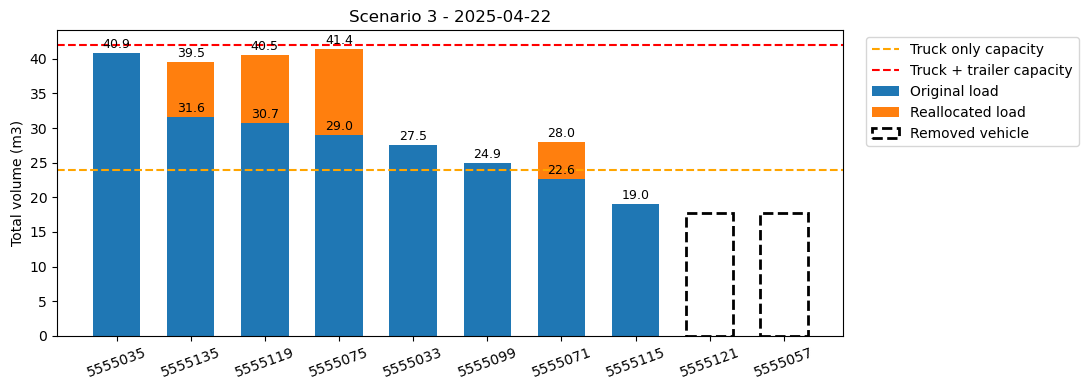

In [ ]:
originalVolume = vehicleTable["totalVolume"].to_numpy()

xValues = np.arange(len(labels)) * 1.25
barWidth = 0.8

fig, axis = plt.subplots(figsize=(11, 4))
barsBefore = axis.bar( xValues, volumeBefore, width=barWidth, label="Original load")
barsAdded = axis.bar( xValues, addedVolume, width=barWidth, bottom=volumeBefore, label="Reallocated load")
axis.axhline(24, color="orange", linestyle="--", label="Truck only capacity")
axis.axhline(42, color="red", linestyle="--", label="Truck + trailer capacity")

for position in removedPositions:
    axis.bar(
        xValues[position],
        originalVolume[position],
        width=barWidth,
        color="none",
        edgecolor="black",
        linestyle="--",
        linewidth=2,
        label="Removed vehicle" if position == removedPositions[0] else None)

addLabels(axis, barsBefore, volumeBefore)
addLabels(axis, barsAdded, addedVolume, bottom=volumeBefore)
axis.set_xticks(xValues)
axis.set_xticklabels([str(vehicle) for vehicle in labels], rotation=20)
axis.set_ylabel("Total volume (m3)")
axis.set_title(f"Scenario 3 - {chosenDate}")
axis.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()

plt.show()

## Create table of moved stops

A result table is also created to show exactly which stops were moved from removed vehicles to remaining vehicles. It includes customer ID, delivery window, original vehicle, new vehicle, stop volume, and predicted service time. This gives more detail than the chart and helps explain how the optimiser solved the disruption. Showing only a limited number of rows keeps the output readable while still illustrating the main reallocations.

In [ ]:
table = movedStops[[
    customerColumn,
    startWindow,
    endWindow,
    "beforeVehicle",
    "afterVehicle",
    "stopVolume",
    "serviceTime"]].head(30).copy()

table[startWindow] = pd.to_datetime(table[startWindow], errors="coerce").dt.strftime("%H:%M")
table[endWindow] = pd.to_datetime(table[endWindow], errors="coerce").dt.strftime("%H:%M")

table["stopVolume"] = pd.to_numeric(table["stopVolume"], errors="coerce").round(1)
table["serviceTime"] = pd.to_numeric(table["serviceTime"], errors="coerce").round(1)

table = table.rename(columns={
    customerColumn: "Customer",
    startWindow: "Window start",
    endWindow: "Window end",
    "beforeVehicle": "Original vehicle",
    "afterVehicle": "New vehicle",
    "stopVolume": "Stop volume",
    "serviceTime": "Service time"})

print(table.to_string(index=False))
print(len(movedStops))

 Customer Window start Window end  Original vehicle  New vehicle  Stop volume  Service time
 379420.0        14:00      15:30           5555121      5555071          5.3          20.3
 651513.0        13:15      14:45           5555121      5555075         12.4          14.2
 930594.0        11:45      15:00           5555057      5555135          7.9          42.3
 944637.0        13:00      14:30           5555057      5555119          9.8          15.0


In [ ]:
import json

with open("new scenario 3.ipynb", "r", encoding="utf-8") as f:
    nb = json.load(f)

for i, cell in enumerate(nb["cells"]):
    if cell["cell_type"] == "code":
        print("\n" + "="*70)
        print(f"CELL {i}")
        print("="*70)
        print("".join(cell["source"]))



CELL 2
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from ortools.constraint_solver import pywrapcp, routing_enums_pb2

CELL 4
chosenDate = "2025-04-22"
topVehicleCount = 10
vehiclesToRemove = 2

fromHour = 8
toHour = 15
capacity = 42
endOfDay = 24 * 60
solveTime = 10

customerColumn = "Kundenr"
dateColumn = "Dato"
shiftColumn = "Kjøreskift ID"
startWindow = "Leveringsvindu fra"
endWindow = "Leveringsvindu til"
predColumn = "predikert_leveringstid"
volumeColumn = "Levert volum (m3)"

CELL 6
def toMinutes(timeValue):
    return timeValue.hour * 60 + timeValue.minute

def addLabels(axis, bars, values, bottom=None):
    for number, bar in enumerate(bars):
        value = values[number]

        if value <= 0:
            continue

        if bottom is None:
            height = value
        else:
            height = bottom[number] + value

        axis.text(
            bar.get_x() + bar.get_width() / 2,
            height + 0.3,
            f"{height:.1f}",
 